In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
type(X_train_scaled)

numpy.ndarray

In [11]:
type(y_train)

pandas.Series

In [12]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

In [14]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [16]:
# Defining ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model=nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1),
            
        )

    def forward(self,x):
        return self.model(x)
    

In [17]:
import torch.optim as optim

In [18]:
model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [19]:
epochs = 100
train_losses=[]
val_losses=[]

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb) # Forward propagation
        loss = criterion(outputs, yb) # Compute the loss
        loss.backward() # Backward propagation
        optimizer.step() # Update the parameters

        running_loss += loss.item()

    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss+=loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch : {epoch+1}/{epochs} ---- train loss:{epoch_train_loss} & val loss:{epoch_val_loss}")
    if(epoch_val_loss<best_val_loss):
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch : 1/100 ---- train loss:205799.65201822916 & val loss:203446.54036458334
epoch : 2/100 ---- train loss:194296.2650390625 & val loss:179383.22942708334
epoch : 3/100 ---- train loss:154068.54524739584 & val loss:125007.962109375
epoch : 4/100 ---- train loss:94857.06381835937 & val loss:67951.8521484375
epoch : 5/100 ---- train loss:49728.5025797526 & val loss:36521.686360677086
epoch : 6/100 ---- train loss:28958.51495361328 & val loss:23596.824674479165
epoch : 7/100 ---- train loss:20189.36423746745 & val loss:17594.82888997396
epoch : 8/100 ---- train loss:15596.487935384115 & val loss:13763.057666015626
epoch : 9/100 ---- train loss:12125.650465901692 & val loss:10463.279850260416
epoch : 10/100 ---- train loss:8984.354626464843 & val loss:7441.195076497396
epoch : 11/100 ---- train loss:6105.709286499024 & val loss:4827.49150390625
epoch : 12/100 ---- train loss:3811.052374267578 & val loss:2965.567637125651
epoch : 13/100 ---- train loss:2295.951045735677 & val loss:1824.72

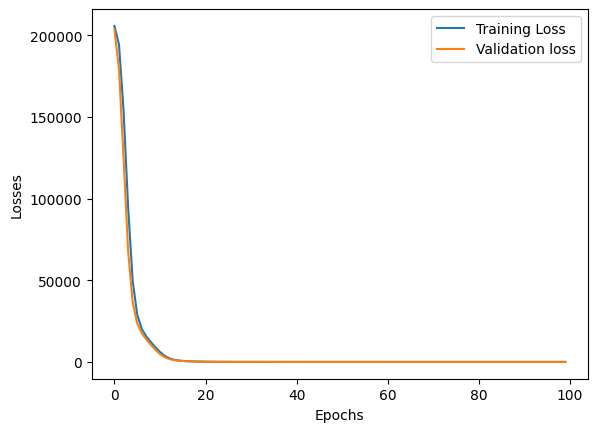

In [20]:
import matplotlib.pyplot as plt


loss_df = pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [21]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [23]:
#Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 21.35368537902832
Testing MSE: 19.560670852661133


In [24]:
from sklearn.metrics import r2_score

print("r2 score:",r2_score(y_test,test_preds))

r2 score: 0.9316405038749731
